# Notebook 10 – Target Variable Analysis
Dataset: `telecom_customer_churn.csv`
Target variable: **churn** (classification)

A **target variable** is the specific outcome or dependent variable that a supervised machine learning model tries to predict based on input features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
df = pd.read_csv("telecom_customer_churn.csv")
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,CUST-10681,Male,0,Yes,No,24.0,Yes,Fiber optic,Month-to-month,Yes,Credit card,80.04,1900.19,No
1,CUST-10024,Female,0,Yes,No,35.0,Yes,Fiber optic,Month-to-month,Yes,Mailed check,42.99,1539.83,No
2,CUST-10621,Male,0,Yes,No,68.0,Yes,DSL,Month-to-month,Yes,Electronic check,79.31,5401.35,Yes
3,CUST-10099,Male,0,Yes,Yes,18.0,Yes,Fiber optic,Month-to-month,Yes,Electronic check,113.02,2022.80,No
4,CUST-10284,Male,1,Yes,Yes,34.0,Yes,No,Month-to-month,No,Electronic check,28.78,966.99,Yes


Loads pandas/numpy for data handling and matplotlib/seaborn for plotting.
                                                            
sns.set_style("whitegrid") gives all charts a clean grid background.
                                                            
Reads the CSV into a DataFrame df and previews the first 5 rows with .head().

## 1. Identify the Target Variable
The target variable is `churn`, indicating whether a customer left the company (`Yes`) or stayed (`No`). This is a **binary classification** problem.

In [2]:
target = "churn"
df[target].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Stores the column name "churn" in a variable for reuse throughout the notebook.
    
.unique() lists the distinct values in that column (Yes, No) to confirm it's a clean binary categorical field.

## 2. Class Distribution

In [3]:
class_counts = df[target].value_counts()
class_counts

churn
No     697
Yes    318
Name: count, dtype: int64

value_counts() counts how many rows fall into each category — gives raw counts of churned vs non-churned customers.

/tmp/ipykernel_529/338517730.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target, order=class_counts.index, palette="Set2")


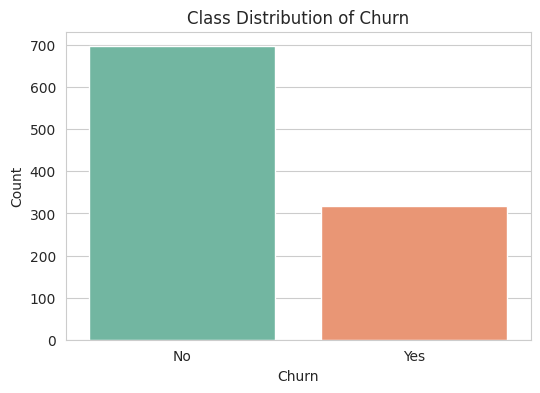

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target, order=class_counts.index, palette="Set2")
plt.title("Class Distribution of Churn")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

sns.countplot draws a bar chart of category frequencies directly from the raw data.
    
order=class_counts.index ensures bars are sorted from most to least frequent.
    
plt.show() renders the chart inline.

## 3. Class Counts

In [5]:
class_counts.to_frame(name="count")

,count
churn,
No,697
Yes,318


Converts the Series from Cell 3 into a tidy one-column DataFrame labeled "count", for cleaner display.

## 4. Class Percentages

In [6]:
class_percentages = df[target].value_counts(normalize=True) * 100
class_percentages.round(2).to_frame(name="percentage")

,percentage
churn,
No,68.67
Yes,31.33


normalize=True converts counts into proportions (0–1) instead of raw counts.
    
Multiplying by 100 converts proportions to percentages; .round(2) keeps 2 decimal places.

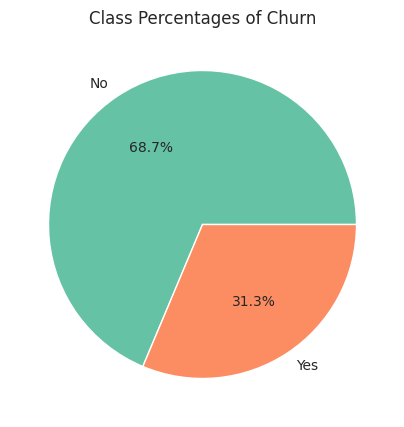

In [7]:
plt.figure(figsize=(5, 5))
plt.pie(class_percentages, labels=class_percentages.index, autopct="%1.1f%%", colors=sns.color_palette("Set2"))
plt.title("Class Percentages of Churn")
plt.show()

plt.pie visualizes the percentage split; autopct="%1.1f%%" prints each slice's percentage with 1 decimal place directly on the chart.

## 5. Class Imbalance

In [8]:
imbalance_ratio = class_counts.max() / class_counts.min()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()
print("Majority class:", majority_class, "-", class_counts.max(), "records")
print("Minority class:", minority_class, "-", class_counts.min(), "records")
print("Imbalance ratio:", round(imbalance_ratio, 2))

Majority class: No - 697 records
Minority class: Yes - 318 records
Imbalance ratio: 2.19


.max()/.min() get the largest and smallest class counts; dividing gives the imbalance ratio (how many times bigger the majority class is).

.idxmax()/.idxmin() retrieve the label (e.g. "No", "Yes") of the majority/minority class rather than just the count.

The print() statements report the findings in plain language.

With a majority-to-minority ratio of roughly 2.2:1, the dataset shows a **moderate class imbalance**. The `No` (not churned) class dominates over the `Yes` (churned) class. This is not extreme, but it can still bias models toward predicting the majority class if not addressed through techniques such as resampling, class weighting, or appropriate evaluation metrics.

## 6. Why Understanding the Target Variable Matters Before Machine Learning

Understanding the target variable before building any model is essential for several reasons:

1. **Determines the problem type** – Knowing whether the target is categorical or continuous decides whether the task is classification or regression, which in turn determines the algorithms, loss functions, and evaluation metrics to use.
2. **Reveals class imbalance** – An imbalanced target can cause models to become biased toward the majority class, producing misleadingly high accuracy while failing to detect the minority class (e.g., churned customers), which is often the class of real business interest.
3. **Guides evaluation metric choice** – For imbalanced targets, accuracy alone is insufficient. Metrics such as precision, recall, F1-score, and ROC-AUC give a more honest picture of performance.
4. **Informs sampling and modeling strategy** – Awareness of imbalance allows the use of techniques like SMOTE, undersampling, oversampling, or class-weighted algorithms to build a fairer model.
5. **Sets a performance baseline** – Knowing the majority class percentage sets a naive baseline (e.g., always predicting "No") that any useful model must outperform.
6. **Prevents data leakage and misinterpretation** – Early analysis of the target helps confirm it is clean, correctly encoded, and free of unexpected categories or missing values before it is used to train a model.

In short, a solid understanding of the target variable ensures that the right problem is being solved, with the right tools, and that model performance is measured meaningfully.